# Impact of socio-economic factors on real estate prices in New York City

## Introduction

Real estate prices in New York City are influenced by a complex interplay of geographic, economic, and social variables. This analysis shows the socio-economic status (SES) of the population and property market values. While location is always important, we can now use data to look deeper into each neighborhood.
By combining real estate transaction data with US Census demographics, this study moves beyond traditional property valuation. We aim to understand why certain areas have higher prices by exploring how variables such as income, professional employment, and commute act as the primary drivers of real estate pricing. We will analyze these trends across all five boroughs: Manhattan, The Bronx, Brooklyn, Queens, and Staten Island.

## Data integration and methodology
To achieve a comprehensive analysis this study merges two datasets:
1. NYC Sales Dataset 2016-2017. It containing transaction prices, property types, and geographical identifiers.
2. US Census Data 2013-2017. It providing demographic and socio-economic metrics at the census tract level.
The connection between these datasets is facilitated through the **Geographic Correspondence** engine allowing us to map census tracts to ZIP codes (ZCTAs) for a precise merge.

**Temporal Alignment (ACS 2017)** \
I use the **ACS 2017 5-year estimates** for the socio-economic part. Even though the property sales data covers a specific period September 2016 - September 2017, the government doesn't publish monthly population data for small neighborhoods. However neighborhood characteristics like income and professional status don't change drastically in a few months. Therefore the 2017 dataset provides a perfect basis for undestanding of the conditions at the time these properties were being sold.

## Analytical framework
The research follows a clear step-by-step process:
1. Data preprocessing \
Cleaning and merging datasets to ensure integrity and alignment. А key step here is Log transformation to handle the right-skewed nature of real estate prices:
$$ \ln(P) = \text{log\_sale\_price} $$

3. Exploratory Data Analysis (EDA) \
Using histograms and scatter plots to visualize trends and relationships. We also use the Pearson correlation coefficient (***r***) to measure the strength and direction of the linear relationship between socio-economic variables and property prices:
$$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}} $$

5. Statistical validation \
Applying Levene’s test to check for homogeneity of variance (homoscedasticity):
$$ H_0: \sigma_1^2 = \sigma_2^2 = \dots = \sigma_k^2 $$
We also use Q-Q plots to verify if our log-transformed data follows a normal distribution.

6. Hypothesis testing \
We use Two-Way ANOVA to see if the Borough and Tax group have a real impact on prices. This is measured by the F-statistic, which compares the differences between groups to the variation within them: Utilizing T-tests and two-way ANOVA to determine how different factors affect the price. 
$$ F = \frac{\text{Variance between boroughs}}{\text{Variance within boroughs}} $$
A high F-value will prove that location and building type are significant drivers of the NYC real estate market. We also use independent T-tests to compare specific pairs of boroughs. This helps us see if the price difference between two areas is statistically significant
county_to_borough = {
    'New York County': 'Manhattan',
    'Kings County': 'Brooklyn',
    'Queens County': 'Queens',
    'Bronx County': 'Bronx',
    'Richmond County': 'Staten Island'
}
7. Bayesian inference \
We use Bayes' theorem to calculate probabilities. For example, if we know a property is "Elite" (in the top 10% of the market), we calculate the probability that it is located in a specific borough:
$$ P(\text{Borough} | \text{Elite}) = \frac{P(\text{Elite} | \text{Borough}) \cdot P(\text{Borough})}{P(\text{Elite})} $$

8. Fourier аnalysis \
We use the Fourier transform to see if the housing market follows any waves or cycles (seasonality) over time:
$$ \hat{f}(\xi) = \int_{-\infty}^{\infty} f(x) e^{-2\pi i x \xi} dx $$


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

## 1. Data cleaning of first dataset - NYC property sales

In [2]:
nyc_dataset = pd.read_csv("nyc-rolling-sales.csv")

In [3]:
nyc_dataset

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84543,8409,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,34,,B9,37 QUAIL LANE,...,2,0,2,2400,2575,1998,1,B9,450000,2016-11-28 00:00:00
84544,8410,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7349,78,,B9,32 PHEASANT LANE,...,2,0,2,2498,2377,1998,1,B9,550000,2017-04-21 00:00:00
84545,8411,5,WOODROW,02 TWO FAMILY DWELLINGS,1,7351,60,,B2,49 PITNEY AVENUE,...,2,0,2,4000,1496,1925,1,B2,460000,2017-07-05 00:00:00
84546,8412,5,WOODROW,22 STORE BUILDINGS,4,7100,28,,K6,2730 ARTHUR KILL ROAD,...,0,7,7,208033,64117,2001,4,K6,11693337,2016-12-21 00:00:00


In [4]:
nyc_dataset.head()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [5]:
nyc_dataset.dtypes

Unnamed: 0                         int64
BOROUGH                            int64
NEIGHBORHOOD                      object
BUILDING CLASS CATEGORY           object
TAX CLASS AT PRESENT              object
BLOCK                              int64
LOT                                int64
EASE-MENT                         object
BUILDING CLASS AT PRESENT         object
ADDRESS                           object
APARTMENT NUMBER                  object
ZIP CODE                           int64
RESIDENTIAL UNITS                  int64
COMMERCIAL UNITS                   int64
TOTAL UNITS                        int64
LAND SQUARE FEET                  object
GROSS SQUARE FEET                 object
YEAR BUILT                         int64
TAX CLASS AT TIME OF SALE          int64
BUILDING CLASS AT TIME OF SALE    object
SALE PRICE                        object
SALE DATE                         object
dtype: object

In [6]:
nyc_dataset.shape

(84548, 22)

In [7]:
nyc_dataset.columns = nyc_dataset.columns.str.lower().str.replace(' ', '_')

In [8]:
nyc_dataset['unnamed:_0']

0           4
1           5
2           6
3           7
4           8
         ... 
84543    8409
84544    8410
84545    8411
84546    8412
84547    8413
Name: unnamed:_0, Length: 84548, dtype: int64

In [9]:
nyc_dataset.drop(columns = ['unnamed:_0'], inplace = True)

In [10]:
nyc_dataset.shape

(84548, 21)

In [11]:
nyc_dataset.isnull().sum()

borough                           0
neighborhood                      0
building_class_category           0
tax_class_at_present              0
block                             0
lot                               0
ease-ment                         0
building_class_at_present         0
address                           0
apartment_number                  0
zip_code                          0
residential_units                 0
commercial_units                  0
total_units                       0
land_square_feet                  0
gross_square_feet                 0
year_built                        0
tax_class_at_time_of_sale         0
building_class_at_time_of_sale    0
sale_price                        0
sale_date                         0
dtype: int64

Some cells maybe contain spaces or dashes ('-') instead of being empty. We need replace them with NaN values to reveal the count of an actual missing data.

In [12]:
nyc_dataset = nyc_dataset.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [13]:
pd.set_option('future.no_silent_downcasting', True)

In [14]:
nyc_dataset.replace(['-', '', ' '], np.nan, inplace = True)

I set the ***future.no_silent_downcasting*** option to True. This ensures the code remains compatible with future versions of Pandas and prevents unnecessary warning messages when replacing values.

In [15]:
nyc_dataset = nyc_dataset.infer_objects(copy=False)

In [16]:
print(nyc_dataset.isnull().sum())

borough                               0
neighborhood                          0
building_class_category               0
tax_class_at_present                738
block                                 0
lot                                   0
ease-ment                         84548
building_class_at_present           738
address                               0
apartment_number                  65496
zip_code                              0
residential_units                     0
commercial_units                      0
total_units                           0
land_square_feet                  26252
gross_square_feet                 27612
year_built                            0
tax_class_at_time_of_sale             0
building_class_at_time_of_sale        0
sale_price                        14561
sale_date                             0
dtype: int64


The columns ***land_square_feet***, ***gross_square_feet***, and ***sale_price*** are currently stored as objects. We need to convert them to numeric types to perform mathematical operations, such as calculating averages or analyzing price trends.

In [17]:
num_cols = ['land_square_feet', 'gross_square_feet', 'sale_price']
for col in num_cols:
    nyc_dataset[col] = pd.to_numeric(nyc_dataset[col], errors = 'coerce')

In [18]:
nyc_dataset.dtypes

borough                             int64
neighborhood                       object
building_class_category            object
tax_class_at_present               object
block                               int64
lot                                 int64
ease-ment                         float64
building_class_at_present          object
address                            object
apartment_number                   object
zip_code                            int64
residential_units                   int64
commercial_units                    int64
total_units                         int64
land_square_feet                  float64
gross_square_feet                 float64
year_built                          int64
tax_class_at_time_of_sale           int64
building_class_at_time_of_sale     object
sale_price                        float64
sale_date                          object
dtype: object

In [19]:
nyc_dataset.sale_price

0         6625000.0
1               NaN
2               NaN
3         3936272.0
4         8000000.0
            ...    
84543      450000.0
84544      550000.0
84545      460000.0
84546    11693337.0
84547       69300.0
Name: sale_price, Length: 84548, dtype: float64

Deleting invalid price values -> ***sale_price < 10 000 & sale_price = 0***, because these values are not real sales. They are inherited estates or business sales. They don't have analytical value for our purpose. Also deleting NaN values, as they would distort with our calculations and could lead to biased or incorrect statistical results.

In [20]:
nyc_dataset.dropna(subset = ['sale_price'], inplace = True)

In [21]:
nyc_dataset.sale_price.isnull().sum()

np.int64(0)

In [22]:
(nyc_dataset.sale_price == 0).sum()

np.int64(10228)

In [23]:
(nyc_dataset.sale_price < 1000).sum()

np.int64(11306)

In [24]:
nyc_dataset = nyc_dataset[nyc_dataset.sale_price >= 10000].copy()

In [25]:
nyc_dataset.shape

(58465, 21)

There are residential and commerce buildings. For our analysis we need residential buildings. We need to remove other. For that purpose we can filter the data with ***tax_building_at_sale_price*** to remove business deals.
#### NYC Property Tax Classes
Class 1 - 1-3 Unit residential: 1- to 3-family homes, small condos, and vacant land zoned residential. These are generally assessed at a lower percentage of market value (6%). \
Class 2 - Apartments & co-ops: Rental apartment buildings, cooperatives, and condominiums with 4 or more units. \
Class 3 - Utility properties: Property owned by utility companies, including special franchise property. \
Class 4 - Commercial & industrial: Office buildings, factories, retail space, and warehouses.

In [26]:
nyc_dataset = nyc_dataset[nyc_dataset['tax_class_at_time_of_sale'].isin([1, 2])].copy()

To ensure our analysis focuses strictly on residential homes we will remove properties that contain any commercial units. This helps us avoid price distortions caused by business.

In [27]:
nyc_dataset = nyc_dataset[nyc_dataset['commercial_units'] == 0]

In [28]:
print(nyc_dataset['commercial_units'].unique())

[0]


Properties with more than three units are typically commercial investments rather than individual homes. To better analyze factors affecting the average person, we have restricted the dataset to properties with 3 units or fewer. This ensures that institutional investments do not skew our findings

In [29]:
nyc_dataset = nyc_dataset[nyc_dataset.total_units <= 3].copy()

In [30]:
len(nyc_dataset)

52962

In [31]:
pd.qcut(nyc_dataset['sale_price'], 10).value_counts().sort_index()

sale_price
(9999.999, 225000.0]       5360
(225000.0, 330000.0]       5356
(330000.0, 425000.0]       5322
(425000.0, 510000.0]       5229
(510000.0, 612000.0]       5219
(612000.0, 730000.0]       5408
(730000.0, 880000.0]       5205
(880000.0, 1155000.0]      5273
(1155000.0, 1817950.0]     5293
(1817950.0, 98525704.0]    5297
Name: count, dtype: int64

In [32]:
nyc_dataset.shape

(52962, 21)

In [33]:
top_20_expensive = nyc_dataset.sort_values(by='sale_price', ascending=False).iloc[0:20]

In [34]:
top_20_expensive[['borough', 'neighborhood', 'total_units', 'residential_units', 'sale_price']]

,borough,neighborhood,total_units,residential_units,sale_price
15983,1,UPPER WEST SIDE (59-79),1,1,98525704.0
7387,1,MIDTOWN CBD,1,1,87660898.0
7383,1,MIDTOWN CBD,1,1,65661755.0
7381,1,MIDTOWN CBD,1,1,65163580.0
17166,1,UPPER WEST SIDE (79-96),1,1,61250000.0
7386,1,MIDTOWN CBD,1,1,60893873.0
11979,1,UPPER EAST SIDE (59-79),0,0,55000000.0
15589,1,UPPER WEST SIDE (59-79),1,1,50550000.0
1399,1,CIVIC CENTER,1,1,47866945.0
9156,1,MIDTOWN WEST,1,1,45824750.0


Refining the dataset to focus on individual residential sales. By selecting Tax Classes 1 and 2 and limiting the properties to 3 units or fewer, we exclude large-scale commercial investments and massive apartment complexes. This leaves us with 53,665 records representing the primary housing market. High-value outliers (up to $98M) are intentionally retained at this stage to observe the full diversity of the NYC luxury sector before final statistical normalization.

The column ease-ment contains no useful information, it is entirely empty, so we are removing it from the dataset.

In [35]:
nyc_dataset = nyc_dataset.drop(columns=['ease-ment']).copy()

The column apartment_number is missing more than 70% of its data. Since it doesn't provide significant value, we have decided to remove it.

In [36]:
nyc_dataset = nyc_dataset.drop(columns = ['apartment_number']).copy()

In [37]:
(nyc_dataset.land_square_feet == 0).sum()

np.int64(7785)

Filling missing values in column ***gross_square_feet*** using the median value for each specific neighborhood. The median is preferred over the mean because real estate data is often skewed by extreme outliers like very large or very small properties.This gives us a more realistic view of a typical property and prevents our analysis from being distorted.

In [38]:
nyc_dataset.land_square_feet = nyc_dataset.groupby('neighborhood')['land_square_feet'].transform(lambda x: x.fillna(x.median()))

In [39]:
nyc_dataset.land_square_feet.isnull().sum()

np.int64(3262)

After the first step, 3252 missing values remain. This occurs because some entire neighborhoods have no data for square footage, making it impossible to calculate a local median. In these cases, we use the median of the entire borough instead. This broader category allows us to fill the remaining gaps effectively.

In [40]:
land_square_medians = nyc_dataset.groupby('borough')['land_square_feet'].transform('median')

In [41]:
nyc_dataset.land_square_feet = nyc_dataset.land_square_feet.fillna(land_square_medians)

In [42]:
nyc_dataset.land_square_feet.isnull().sum()

np.int64(0)

In [43]:
(nyc_dataset['year_built'] == 0).sum()

np.int64(3648)

The ***year_built*** column has values of 0, which is impossible. I will replace these zeros with the median year of each neighborhood. This ensures every property has a realistic construction year based on its location.

In [44]:
nyc_dataset['year_built'] = nyc_dataset['year_built'].replace(0, np.nan)

In [45]:
nyc_dataset['year_built'] = nyc_dataset.groupby('neighborhood')['year_built'].transform(lambda x: x.fillna(x.median()))

In [46]:
(nyc_dataset['year_built'] == 0).sum()

np.int64(0)

Converting ***sale_date*** to datetime format and extracting the day of the week to analyze sales patterns.

In [47]:
nyc_dataset.sale_date = pd.to_datetime(nyc_dataset.sale_date, errors = 'coerce')

In [48]:
nyc_dataset['sale_date'] = nyc_dataset['sale_date'].dt.date

In [49]:
nyc_dataset['sale_date'] = pd.to_datetime(nyc_dataset['sale_date'])

In [50]:
nyc_dataset['sale_day_of_week'] = nyc_dataset['sale_date'].dt.day_name()

In [51]:
print(nyc_dataset[['sale_date', 'sale_day_of_week']].head())

    sale_date sale_day_of_week
13 2017-03-10           Friday
15 2017-06-09           Friday
16 2017-07-14           Friday
17 2017-03-16         Thursday
18 2016-09-01         Thursday


In [52]:
nyc_dataset['sale_day_of_week'].value_counts()

sale_day_of_week
Thursday     12482
Wednesday    10893
Friday       10601
Tuesday      10183
Monday        8669
Saturday        85
Sunday          49
Name: count, dtype: int64

We checked the sale dates to see which days are the busiest. Almost all sales happen on weekdays, with Thursday being the most popular day. Very few sales happen on weekends because banks and lawyers are closed. This confirms that our data is realistic.
A very small number of sales are recorded on weekends. This could be due to private contracts signed on those days or minor data entry errors. However, since it's less than 0.3%, it doesn't affect our overall analysis.

Standardizing text data in colomns ***neighborhood***, ***category***, and ***address***.

In [53]:
cols_to_fix = ['neighborhood', 'building_class_category', 'address']
for col in cols_to_fix:
    nyc_dataset[col] = nyc_dataset[col].str.strip().str.title()

In [54]:
nyc_dataset

,borough,neighborhood,building_class_category,tax_class_at_present,block,lot,building_class_at_present,address,zip_code,residential_units,commercial_units,total_units,land_square_feet,gross_square_feet,year_built,tax_class_at_time_of_sale,building_class_at_time_of_sale,sale_price,sale_date,sale_day_of_week
13,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3 Street, 1C",10009,0,0,0,1825.5,NaN,1920.0,2,C6,499000.0,2017-03-10,Friday
15,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3Rd Street, 5A",10009,0,0,0,1825.5,NaN,1920.0,2,C6,529500.0,2017-06-09,Friday
16,1,Alphabet City,09 Coops - Walkup Apartments,2,373,40,C6,"327 East 3 Street, 2E",10009,0,0,0,1825.5,NaN,1920.0,2,C6,423000.0,2017-07-14,Friday
17,1,Alphabet City,09 Coops - Walkup Apartments,2,373,46,C6,"317 East 3Rd Street, 12",10009,0,0,0,1825.5,NaN,1925.0,2,C6,501000.0,2017-03-16,Thursday
18,1,Alphabet City,09 Coops - Walkup Apartments,2,373,49,C6,"311 East 3Rd Street, 17",10009,0,0,0,1825.5,NaN,1920.0,2,C6,450000.0,2016-09-01,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84540,5,Woodrow,02 Two Family Dwellings,1,7316,93,B2,125 Darnell Lane,10309,2,0,2,3325.0,1300.0,1995.0,1,B2,509000.0,2016-10-31,Monday
84541,5,Woodrow,02 Two Family Dwellings,1,7317,126,B2,112 Robin Court,10309,2,0,2,11088.0,2160.0,1994.0,1,B2,648000.0,2016-12-07,Wednesday
84543,5,Woodrow,02 Two Family Dwellings,1,7349,34,B9,37 Quail Lane,10309,2,0,2,2400.0,2575.0,1998.0,1,B9,450000.0,2016-11-28,Monday
84544,5,Woodrow,02 Two Family Dwellings,1,7349,78,B9,32 Pheasant Lane,10309,2,0,2,2498.0,2377.0,1998.0,1,B9,550000.0,2017-04-21,Friday


In [55]:
nyc_dataset.duplicated().sum()

np.int64(73)

In [56]:
nyc_dataset = nyc_dataset.drop_duplicates()

In [57]:
nyc_dataset = nyc_dataset.copy()

We need to drop the ***'at present'*** tax and building class columns because we are only interested in the information at the time of the sale. This keeps the dataset focused on the historical transaction data.

In [58]:
nyc_dataset.drop(columns = ['building_class_at_present', 'tax_class_at_present'], inplace = True)

### 2. Data cleaning of second dataset - NYC census tract

We will use the **ACS 2017 5-year estimates** (Version 3 of the Kaggle dataset). Although the general description mentions 2015, the specific file acs2017_census_tract_data.csv contains the updated data for the 2013-2017 period. \
The original dataset contains census data for the entire United States. We will filter it to include only **New York City** by selecting the five specific counties that make up the city - **New York (Manhattan)**, **Kings (Brooklyn)**, **Queens**, **Bronx**, and **Richmond (Staten Island)**. This allows us to focus our socio-economic analysis exclusively on the NYC area. \

This dataset provides a detailed profile of each neighborhood through several key categories:
1. Demographics - total population and ethnic diversity (white, black, hispanic, asian, etc.) 
2. Income and wealth - median household income, income per capita, and poverty rates. 
3. Employment/unemployment rates and occupation types (professional, service, construction, etc.).
4. Commuting - common transport methods (public, transit, walking, driving) and average commute times.

A Census Tract ID is a unique identification number assigned to small geographic areas by the Census Bureau. It acts as a "common key" that allows us to link property sales to the specific socio-economic data, like income and poverty, of the area where the building is located.


In [59]:
#Census data for the entire United States
us_census_data = pd.read_csv('acs2017_census_tract_data.csv')

In [60]:
us_census_data

,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73996,72153750501,Puerto Rico,Yauco Municipio,6011,3035,2976,99.7,0.3,0.0,0.0,...,0.5,0.0,3.6,26.9,1576,59.2,33.8,7.0,0.0,20.8
73997,72153750502,Puerto Rico,Yauco Municipio,2342,959,1383,99.1,0.9,0.0,0.0,...,0.0,0.0,1.3,25.3,666,58.4,35.4,6.2,0.0,26.3
73998,72153750503,Puerto Rico,Yauco Municipio,2218,1001,1217,99.5,0.2,0.0,0.0,...,3.4,0.0,3.4,23.5,560,57.5,34.5,8.0,0.0,23.0
73999,72153750601,Puerto Rico,Yauco Municipio,4380,1964,2416,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,24.1,1062,67.7,30.4,1.9,0.0,29.5


In [61]:
#Filter the data to include only NYC counties
nyc_counties = ['New York County', 'Kings County', 'Queens County', 'Bronx County', 'Richmond County']

In [62]:
nyc_census = us_census_data[(us_census_data['State'] == 'New York') & 
                         (us_census_data['County'].isin(nyc_counties))].copy()

In [63]:
county_to_borough = {
    'New York County': 'Manhattan',
    'Kings County': 'Brooklyn',
    'Queens County': 'Queens',
    'Bronx County': 'Bronx',
    'Richmond County': 'Staten Island'
}

In [64]:
#Add a new column 'borough' for easier recognition
nyc_census['borough'] = nyc_census['County'].map(county_to_borough)

To make the data more readable we created a mapping dictionary to convert official county names (like Kings County) into their well-known borough names (like Brooklyn). Finally, we added a new borough column to the dataset for easier identification during analysis.

In [65]:
nyc_census

,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment,borough
43283,36005000100,New York,Bronx County,7411,6857,554,32.0,7.2,57.6,0.3,...,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,Bronx
43284,36005000200,New York,Bronx County,5058,2502,2556,77.7,0.8,18.4,0.0,...,0.9,0.5,41.8,1858,75.1,18.9,5.9,0.0,12.4,Bronx
43285,36005000400,New York,Bronx County,5944,2984,2960,66.4,3.4,28.6,0.0,...,0.6,1.9,47.7,2917,67.2,28.7,4.0,0.0,7.4,Bronx
43286,36005001600,New York,Bronx County,6115,2351,3764,63.3,3.7,31.1,0.0,...,0.0,3.9,38.6,2120,71.0,26.6,2.5,0.0,9.1,Bronx
43287,36005001900,New York,Bronx County,2817,1327,1490,53.4,7.7,33.1,0.0,...,1.9,1.9,44.1,1290,75.3,16.7,8.0,0.0,13.4,Bronx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47144,36085030302,New York,Richmond County,6560,3459,3101,38.5,33.4,11.9,0.0,...,0.0,1.3,48.6,2721,73.6,24.2,2.1,0.0,4.0,Staten Island
47145,36085031901,New York,Richmond County,2737,1060,1677,32.9,6.7,57.1,0.0,...,0.0,0.0,45.0,683,77.0,17.9,5.1,0.0,8.1,Staten Island
47146,36085031902,New York,Richmond County,5140,2409,2731,35.1,8.7,51.8,0.0,...,0.0,0.5,49.8,1714,82.3,15.3,2.5,0.0,4.6,Staten Island
47147,36085032300,New York,Richmond County,1136,578,558,29.3,22.7,45.7,0.0,...,0.0,0.0,47.3,544,80.9,15.6,3.5,0.0,4.9,Staten Island


In [66]:
nyc_census.drop(columns=['State'], inplace=True)

Since we have already filtered the data for New York City, the **State** column is no longer necessary. I drop it to keep the dataset clean.

In [67]:
nyc_census.dtypes

TractId               int64
County               object
TotalPop              int64
Men                   int64
Women                 int64
Hispanic            float64
White               float64
Black               float64
Native              float64
Asian               float64
Pacific             float64
VotingAgeCitizen      int64
Income              float64
IncomeErr           float64
IncomePerCap        float64
IncomePerCapErr     float64
Poverty             float64
ChildPoverty        float64
Professional        float64
Service             float64
Office              float64
Construction        float64
Production          float64
Drive               float64
Carpool             float64
Transit             float64
Walk                float64
OtherTransp         float64
WorkAtHome          float64
MeanCommute         float64
Employed              int64
PrivateWork         float64
PublicWork          float64
SelfEmployed        float64
FamilyWork          float64
Unemployment        

In [68]:
nyc_census.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower() for col in nyc_census.columns]

The first dataset is already in this format. By standardizing the second dataset to match, we ensure that both tables use a consistent snake_case naming convention. This makes it much easier to perform the merge and reference columns.

In [69]:
nyc_census.columns

Index(['tract_id', 'county', 'total_pop', 'men', 'women', 'hispanic', 'white',
       'black', 'native', 'asian', 'pacific', 'voting_age_citizen', 'income',
       'income_err', 'income_per_cap', 'income_per_cap_err', 'poverty',
       'child_poverty', 'professional', 'service', 'office', 'construction',
       'production', 'drive', 'carpool', 'transit', 'walk', 'other_transp',
       'work_at_home', 'mean_commute', 'employed', 'private_work',
       'public_work', 'self_employed', 'family_work', 'unemployment',
       'borough'],
      dtype='object')

In [70]:
nyc_census.isnull().sum()

tract_id               0
county                 0
total_pop              0
men                    0
women                  0
hispanic              40
white                 40
black                 40
native                40
asian                 40
pacific               40
voting_age_citizen     0
income                66
income_err            66
income_per_cap        48
income_per_cap_err    48
poverty               43
child_poverty         60
professional          45
service               45
office                45
construction          45
production            45
drive                 45
carpool               45
transit               45
walk                  45
other_transp          45
work_at_home          45
mean_commute          62
employed               0
private_work          45
public_work           45
self_employed         45
family_work           45
unemployment          45
borough                0
dtype: int64

In [71]:
(nyc_census.isnull().mean() * 100).round(2)

tract_id              0.00
county                0.00
total_pop             0.00
men                   0.00
women                 0.00
hispanic              1.85
white                 1.85
black                 1.85
native                1.85
asian                 1.85
pacific               1.85
voting_age_citizen    0.00
income                3.05
income_err            3.05
income_per_cap        2.22
income_per_cap_err    2.22
poverty               1.98
child_poverty         2.77
professional          2.08
service               2.08
office                2.08
construction          2.08
production            2.08
drive                 2.08
carpool               2.08
transit               2.08
walk                  2.08
other_transp          2.08
work_at_home          2.08
mean_commute          2.86
employed              0.00
private_work          2.08
public_work           2.08
self_employed         2.08
family_work           2.08
unemployment          2.08
borough               0.00
d

In [72]:
nyc_census.dropna(inplace = True)

We checked for missing values and found that they represented a very small percentage of the dataset. I decided to drop these rows to ensure that our analysis is based only on complete and reliable information. 

In [73]:
nyc_census.isnull().sum()

tract_id              0
county                0
total_pop             0
men                   0
women                 0
hispanic              0
white                 0
black                 0
native                0
asian                 0
pacific               0
voting_age_citizen    0
income                0
income_err            0
income_per_cap        0
income_per_cap_err    0
poverty               0
child_poverty         0
professional          0
service               0
office                0
construction          0
production            0
drive                 0
carpool               0
transit               0
walk                  0
other_transp          0
work_at_home          0
mean_commute          0
employed              0
private_work          0
public_work           0
self_employed         0
family_work           0
unemployment          0
borough               0
dtype: int64

In [74]:
nyc_census.duplicated().sum()

np.int64(0)

## 3. Add Geographical correlation table

To perform a meaningful socio-economic analysis, we need to combine our Property sales data with the NYC Census data. However, there is no direct link between these two datasets as they use different scales of location data:
* **The sales dataset** identifies locations by neighborhood names and addresses.
* **The census dataset** identifies locations using unique numerical codes called **Census Tract IDs**.

To connect them we use a mapping table Geographic correlation **geocorr** (sourced from the Geocorr 2022 application). This table is a ***geographic translator***. It provides a **crosswalk** that links specific ZIP codes to their corresponding Census Tract IDs.\
By using the geocorr table, we can assign the correct Tract ID to each property sale. This ID becomes our **common key** which is the essential link that allows the two datasets to be merged accurately. 

Once merged each property sale is paired with local economic indicators, such as median household income and employment levels. This integration is crucial for understanding how the socio-economic characteristics of a neighborhood influence real estate prices in New York City.

In [75]:
geocorr = pd.read_csv("geocorr2022_2610506628.csv")

In [76]:
geocorr

,zcta,county,tract,CountyName,ZIPName,hus20,IntPtLat,IntPtLon,afact2,afact
0,ZIP census tabulation area,County code,Tract,County name,ZIP Code name,Total housing units (2020 Census),Weighted centroid latitude,Weighted centroid west longitude,tract-to-zcta allocation factor,zcta-to-tract allocation factor
1,,36005,0504.00,Bronx NY,[not in a ZCTA],1,40.850219,-73.805066,0.5,0.023256
2,,36027,1408.01,Dutchess NY,[not in a ZCTA],1,41.583854,-73.948315,0.000926,0.023256
3,,36033,9509.00,Franklin NY,[not in a ZCTA],1,44.136139,-74.310263,0.000496,0.023256
4,,36041,9501.00,Hamilton NY,[not in a ZCTA],4,44.109082,-74.292252,0.001597,0.093023
...,...,...,...,...,...,...,...,...,...,...
9955,14905,36015,0004.00,Chemung NY,"Elmira, NY",505,42.101187,-76.831903,0.47507,0.117963
9956,14905,36015,0005.00,Chemung NY,"Elmira, NY",1166,42.08548,-76.823281,0.769129,0.272366
9957,14905,36015,0006.00,Chemung NY,"Elmira, NY",235,42.086535,-76.814068,0.169553,0.054894
9958,14905,36015,0103.02,Chemung NY,"Elmira, NY",138,42.084766,-76.872976,0.095634,0.032235


The table includes a descriptive second header row that explains what each column means. Since this row is not actual data we will drop the first line (index 0) to ensure the dataset contains only clean records for analysis

In [77]:
geocorr = geocorr.drop(0,  errors='ignore')

In [78]:
geocorr.dtypes

zcta          object
county        object
tract         object
CountyName    object
ZIPName       object
hus20         object
IntPtLat      object
IntPtLon      object
afact2        object
afact         object
dtype: object

Some cells in the zcta (ZIP code) column appear empty but may contain hidden spaces. I will replace these empty strings with NaN values. This allows Pandas to correctly identify them if there is a missing data, which is essential for a clean and accurate merge.

In [79]:
geocorr['zcta'] = geocorr['zcta'].replace(r'^\s*$', np.nan, regex=True)

In [80]:
geocorr.isnull().sum()

zcta          18
county         0
tract          0
CountyName     0
ZIPName        0
hus20          0
IntPtLat       0
IntPtLon       0
afact2         0
afact          0
dtype: int64

In [81]:
#cleaning the empty data
geocorr = geocorr.dropna(subset=['zcta'])

In [82]:
geocorr.isnull().sum()

zcta          0
county        0
tract         0
CountyName    0
ZIPName       0
hus20         0
IntPtLat      0
IntPtLon      0
afact2        0
afact         0
dtype: int64

In [83]:
geocorr.zcta

19      06390
20      10001
21      10001
22      10001
23      10001
        ...  
9955    14905
9956    14905
9957    14905
9958    14905
9959    14905
Name: zcta, Length: 9941, dtype: object

In [84]:
nyc_census.dtypes

tract_id                int64
county                 object
total_pop               int64
men                     int64
women                   int64
hispanic              float64
white                 float64
black                 float64
native                float64
asian                 float64
pacific               float64
voting_age_citizen      int64
income                float64
income_err            float64
income_per_cap        float64
income_per_cap_err    float64
poverty               float64
child_poverty         float64
professional          float64
service               float64
office                float64
construction          float64
production            float64
drive                 float64
carpool               float64
transit               float64
walk                  float64
other_transp          float64
work_at_home          float64
mean_commute          float64
employed                int64
private_work          float64
public_work           float64
self_emplo

In [85]:
nyc_census.tract_id = nyc_census.tract_id.astype(str)

We need a common key (shared columns) to merge the two datasets. Our key will be the Census Tract FIPS code, but the formats differ. In the nyc_census, it is a full 11-digit code (36005000100), while in geocorr the components are separate. We will fix this by creating a matching FIPS key using the following function.
А full FIPS code include three parts:
1. State code (2 digits): 36 for New York State.
2. County code (3 digits): e.g., 005 for Bronx County.
3. Tract number (6 digits): e.g., 000100 for a specific neighborhood area.\

We will fix this by creating a matching FIPS key in the geocorr table:


In [86]:
def convert_to_fips(row):
    county = str(row['county']).strip()
    tract = str(row['tract']).replace('.','')
    tract = tract.zfill(6)
    return county + tract

We create **convert_to_fips** to build a full 11-digit FIPS code. It strips extra spaces from the county and removes decimals from the tract ID.

By using **.zfill(6)**, we ensure that every tract number is padded with leading zeros to maintain a consistent 6-digit length.

In [87]:
geocorr['full_fips'] = geocorr.apply(convert_to_fips, axis=1)

We apply this function to the geocorr table to create a new full_fips column.

In [88]:
census_with_zip = pd.merge(
    nyc_census, 
    geocorr[['full_fips', 'zcta']], 
    left_on='tract_id', 
    right_on='full_fips', 
    how='inner'
)

In [89]:
census_with_zip

,tract_id,county,total_pop,men,women,hispanic,white,black,native,asian,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough,full_fips,zcta
0,36005000200,Bronx County,5058,2502,2556,77.7,0.8,18.4,0.0,3.1,...,41.8,1858,75.1,18.9,5.9,0.0,12.4,Bronx,36005000200,10473
1,36005000400,Bronx County,5944,2984,2960,66.4,3.4,28.6,0.0,0.6,...,47.7,2917,67.2,28.7,4.0,0.0,7.4,Bronx,36005000400,10473
2,36005001600,Bronx County,6115,2351,3764,63.3,3.7,31.1,0.0,0.0,...,38.6,2120,71.0,26.6,2.5,0.0,9.1,Bronx,36005001600,10473
3,36005002300,Bronx County,4733,2218,2515,60.2,0.2,37.4,1.6,0.0,...,41.4,1271,81.6,15.5,2.9,0.0,18.2,Bronx,36005002300,10454
4,36005002500,Bronx County,5760,2666,3094,76.7,2.4,20.2,0.0,0.1,...,40.2,2212,89.0,3.9,6.7,0.4,6.5,Bronx,36005002500,10454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2618,36085030302,Richmond County,6560,3459,3101,38.5,33.4,11.9,0.0,12.4,...,48.6,2721,73.6,24.2,2.1,0.0,4.0,Staten Island,36085030302,10303
2619,36085030302,Richmond County,6560,3459,3101,38.5,33.4,11.9,0.0,12.4,...,48.6,2721,73.6,24.2,2.1,0.0,4.0,Staten Island,36085030302,10314
2620,36085031901,Richmond County,2737,1060,1677,32.9,6.7,57.1,0.0,3.3,...,45.0,683,77.0,17.9,5.1,0.0,8.1,Staten Island,36085031901,10303
2621,36085031902,Richmond County,5140,2409,2731,35.1,8.7,51.8,0.0,0.9,...,49.8,1714,82.3,15.3,2.5,0.0,4.6,Staten Island,36085031902,10303


We perform an inner merge between our census data and the geocorr mapping. This results in the census_with_zip table, which successfully links socio-economic indicators to their corresponding ZIP codes (zcta).

## 4. Merging datasets census_with_zip and nyc_dataset

In [90]:
zip_col = [col for col in nyc_dataset.columns if 'ZIP' in col.upper()][0]

In [91]:
nyc_dataset[zip_col] = nyc_dataset[zip_col].astype(str)

In [92]:
merged_dataset = pd.merge(
    nyc_dataset, 
    census_with_zip, 
    left_on=zip_col, 
    right_on='zcta', 
    how='inner'
)

In [93]:
merged_dataset

,borough_x,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough_y,full_fips,zcta
0,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,38.9,1213,79.2,16.2,3.6,1.0,9.5,Manhattan,36061002000,10009
1,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,30.1,1392,88.3,2.4,9.3,0.0,4.8,Manhattan,36061002202,10009
2,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,40.0,1068,73.3,21.4,5.2,0.0,14.9,Manhattan,36061002400,10009
3,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,33.6,1980,79.1,16.0,4.9,0.0,5.7,Manhattan,36061002601,10009
4,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,32.2,2781,82.1,8.0,8.6,1.3,4.1,Manhattan,36061002602,10009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869274,5,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,...,47.1,3638,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
869275,5,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,...,44.5,2672,75.9,20.8,3.3,0.0,3.0,Staten Island,36085020804,10309
869276,5,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,...,48.1,2569,70.2,29.8,0.0,0.0,4.6,Staten Island,36085024401,10309
869277,5,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,...,43.9,2234,74.4,22.5,3.1,0.0,7.8,Staten Island,36085024402,10309


In [94]:
merged_dataset.columns

Index(['borough_x', 'neighborhood', 'building_class_category', 'block', 'lot',
       'address', 'zip_code', 'residential_units', 'commercial_units',
       'total_units', 'land_square_feet', 'gross_square_feet', 'year_built',
       'tax_class_at_time_of_sale', 'building_class_at_time_of_sale',
       'sale_price', 'sale_date', 'sale_day_of_week', 'tract_id', 'county',
       'total_pop', 'men', 'women', 'hispanic', 'white', 'black', 'native',
       'asian', 'pacific', 'voting_age_citizen', 'income', 'income_err',
       'income_per_cap', 'income_per_cap_err', 'poverty', 'child_poverty',
       'professional', 'service', 'office', 'construction', 'production',
       'drive', 'carpool', 'transit', 'walk', 'other_transp', 'work_at_home',
       'mean_commute', 'employed', 'private_work', 'public_work',
       'self_employed', 'family_work', 'unemployment', 'borough_y',
       'full_fips', 'zcta'],
      dtype='object')

In [95]:
merged_dataset.head()

,borough_x,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough_y,full_fips,zcta
0,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,38.9,1213,79.2,16.2,3.6,1.0,9.5,Manhattan,36061002000,10009
1,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,30.1,1392,88.3,2.4,9.3,0.0,4.8,Manhattan,36061002202,10009
2,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,40.0,1068,73.3,21.4,5.2,0.0,14.9,Manhattan,36061002400,10009
3,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,33.6,1980,79.1,16.0,4.9,0.0,5.7,Manhattan,36061002601,10009
4,1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,...,32.2,2781,82.1,8.0,8.6,1.3,4.1,Manhattan,36061002602,10009


In [96]:
merged_dataset.drop(columns=['borough_x'], inplace=True)

In [97]:
merged_dataset = merged_dataset.rename(columns={'borough_y': 'borough'})

In [98]:
merged_dataset

,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,land_square_feet,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough,full_fips,zcta
0,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,38.9,1213,79.2,16.2,3.6,1.0,9.5,Manhattan,36061002000,10009
1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,30.1,1392,88.3,2.4,9.3,0.0,4.8,Manhattan,36061002202,10009
2,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,40.0,1068,73.3,21.4,5.2,0.0,14.9,Manhattan,36061002400,10009
3,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,33.6,1980,79.1,16.0,4.9,0.0,5.7,Manhattan,36061002601,10009
4,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,32.2,2781,82.1,8.0,8.6,1.3,4.1,Manhattan,36061002602,10009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869274,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,47.1,3638,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
869275,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,44.5,2672,75.9,20.8,3.3,0.0,3.0,Staten Island,36085020804,10309
869276,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,48.1,2569,70.2,29.8,0.0,0.0,4.6,Staten Island,36085024401,10309
869277,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,43.9,2234,74.4,22.5,3.1,0.0,7.8,Staten Island,36085024402,10309


In [99]:
len(merged_dataset[merged_dataset['sale_price'] > 5000000])

10613

### 5. Data exploration

In [100]:
#Identifying properties with zero recorded units
len(merged_dataset.loc[merged_dataset['total_units'] == 0, 'sale_price'])

225764

In [101]:
merged_dataset.loc[merged_dataset['total_units'] == 0, 'building_class_category'].value_counts().head(10)

building_class_category
10 Coops - Elevator Apartments       171739
09 Coops - Walkup Apartments          31946
17 Condo Coops                        11732
05 Tax Class 1 Vacant Land             5533
13 Condos - Elevator Apartments        3336
06 Tax Class 1 - Other                  609
15 Condos - 2-10 Unit Residential       546
04 Tax Class 1 Condos                   259
11 Special Condo Billing Lots            26
02 Two Family Dwellings                  25
Name: count, dtype: int64

A significant numbers of the dataset 225,764 records shows zero total units. At first glance, this might appear to be a data entry error. However, a breakdown of the building categories reveals that the majority of these entries consist of Co-operative Apartments (Co-ops) and Vacant Land. In New York City real estate records, Co-ops are often listed with zero physical units because the transaction involves the transfer of shares in a corporation rather than a traditional deed to a physical space

In [102]:
merged_dataset.loc[merged_dataset['total_units'] == 0, ['building_class_category', 'sale_price']].value_counts().head(10)

building_class_category         sale_price
10 Coops - Elevator Apartments  250000.0      1805
                                200000.0      1590
                                190000.0      1428
                                300000.0      1426
                                165000.0      1408
                                175000.0      1391
                                280000.0      1383
                                220000.0      1336
                                450000.0      1307
                                275000.0      1288
Name: count, dtype: int64

The frequency analysis of 'zero-unit' properties shows that the most common transactions are Co-operative apartments priced between $165,000 and $450,000. The high volume of sales at these price points confirms that these records represent the core residential market for average-income households. This evidence justifies keeping these records in our dataset.

In [103]:
merged_dataset[merged_dataset['total_units'] == 0].groupby('building_class_category')['sale_price'].mean().sort_values(ascending=False)

building_class_category
13 Condos - Elevator Apartments      1.430612e+06
15 Condos - 2-10 Unit Residential    1.189927e+06
04 Tax Class 1 Condos                1.078593e+06
17 Condo Coops                       8.940001e+05
05 Tax Class 1 Vacant Land           8.288411e+05
02 Two Family Dwellings              7.127750e+05
10 Coops - Elevator Apartments       6.218379e+05
11 Special Condo Billing Lots        6.000000e+05
06 Tax Class 1 - Other               5.739787e+05
09 Coops - Walkup Apartments         4.804302e+05
01 One Family Dwellings              3.812640e+05
Name: sale_price, dtype: float64

In [144]:
zeros_units = merged_dataset[merged_dataset['total_units'] == 0].copy()
zeros_units['price_bin'] = pd.qcut(zeros_units['sale_price'], 10)
print(zeros_units['price_bin'].value_counts().sort_index())

price_bin
(9999.999, 151391.0]       22040
(151391.0, 195000.0]       22426
(195000.0, 245000.0]       22456
(245000.0, 290000.0]       21755
(290000.0, 350000.0]       21538
(350000.0, 440000.0]       22417
(440000.0, 580402.0]       21577
(580402.0, 766000.0]       21979
(766000.0, 1250000.0]      22411
(1250000.0, 55000000.0]    21632
Name: count, dtype: int64


To better understand the economic diversity, we divided the records into ten equal groups based on their sale price. Each group contains approximately 22 000 - 23 000 transactions. This segmentation allows us to observe the market spectrum, ranging from entry-level housing (starting at ~ 10 000) to ultra-luxury investments (reaching up to $55 million). This step is essential for our subsequent analysis of how local income levels correlate with these different price tiers.

In [105]:
zeros_units.groupby('price_bin', observed=False)['income_per_cap'].mean()

price_bin
(9999.999, 150000.0]        31857.058918
(150000.0, 195000.0]        31870.176093
(195000.0, 245000.0]        32967.121620
(245000.0, 290000.0]        33955.058834
(290000.0, 350000.0]        40721.371387
(350000.0, 440000.0]        50640.180259
(440000.0, 585000.0]        63224.158105
(585000.0, 772000.0]        76764.875999
(772000.0, 1250000.0]       85819.949987
(1250000.0, 55000000.0]    102868.866119
Name: income_per_cap, dtype: float64

The grouping of price against income per capita reveals a strong positive correlation. As the property value increases, the average income of the residents in that area also rises significantly.
Also the data reveals a critical gap. The top price decile includes properties up to 55 mln, yet the average income in those areas is only $102,868. This income-to-price ratio is financially impossible for a standard residential purchase. It serves as definitive proof that high-end NYC real estate functions as an investment vehicle for global capital, rather than housing supported by local wages.

In [106]:
merged_dataset['building_class_category'].str.contains('Land').sum()

np.int64(6111)

We examined properties categorized as ***Vacant Land***. Since our goal is to study the socio-economic impact on residential housing, land transactions may introduce noise due to speculative development value. Depending on their volume and price distribution, we will decide whether to exclude them to focus strictly on the lived-in environment

In [107]:
merged_dataset = merged_dataset[~merged_dataset['building_class_category'].str.contains('Land', na=False)]

In [110]:
len(merged_dataset[merged_dataset['sale_price'] > 5_000_000])

10487

Properties with a sale price exceeding $5,000,000 are segmented as a high-end real estate market. This subset represents 10,613 transactions that act as capital-preservation assets rather than typical consumer housing. By isolating these outliers we can distinguish between community-based socio-economic trends and global investment flows.

In [139]:
overall_stats = merged_dataset[['sale_price', 'income_per_cap']].describe()
print(overall_stats)

         sale_price  income_per_cap
count  8.631680e+05   863168.000000
mean   8.526191e+05    41077.393540
std    1.532570e+06    32356.486182
min    1.000000e+04     7222.000000
25%    3.610000e+05    22839.000000
50%    5.800000e+05    30237.000000
75%    9.000000e+05    42290.000000
max    9.852570e+07   220253.000000


In [112]:
#Group by borough
neighborhood_analysis = merged_dataset.groupby('borough').agg({
    'sale_price': 'mean',
    'income_per_cap': 'mean'
})

                 sale_price  income_per_cap  affordability_ratio
borough                                                         
Brooklyn       8.443429e+05    33811.326550            24.972192
Manhattan      2.011167e+06    99160.642083            20.281912
Queens         5.619593e+05    29803.533715            18.855458
Bronx          3.915227e+05    24631.100874            15.895460
Staten Island  4.877763e+05    35572.003896            13.712366


In [140]:
neighborhood_analysis['affordability_ratio'] = neighborhood_analysis['sale_price'] / neighborhood_analysis['income_per_cap']

In [141]:
print(neighborhood_analysis.sort_values(by = 'affordability_ratio', ascending = False).head(10))

                 sale_price  income_per_cap  affordability_ratio
borough                                                         
Brooklyn       8.443429e+05    33811.326550            24.972192
Manhattan      2.011167e+06    99160.642083            20.281912
Queens         5.619593e+05    29803.533715            18.855458
Bronx          3.915227e+05    24631.100874            15.895460
Staten Island  4.877763e+05    35572.003896            13.712366


In [142]:
correlation = merged_dataset['income_per_cap'].corr(merged_dataset['sale_price'])
print(f"Correlation Income per cap - Sale_price: {correlation:.2f}")

Correlation Income per cap - Sale_price: 0.32


The initial analysis shows a weak correlation of 0.32 between income and sale price for the entire dataset. Furthermore the affordability ratio in boroughs like Brooklyn (24.97) and Manhattan (20.28) indicates that property prices are significantly decoupled from local earnings. This statistical noise is caused by high-value investment outliers, justifying our next step: filtering the data to properties under 5 mln to find the true SES correlation for the average resident. \
We set the threshold at 5 mln to account for the gap between annual income and accumulated wealth. While a 220k salary typically supports a 1 mln home, many high-income residents use savings, bonuses, or equity to purchase properties in the 2 to 5 mln range. Therefore 5 mln represents the practical upper limit of the residential market. However, anything above this mark shows a complete statistical break from local wages, as no amount of local savings can justify a 50 mln or 100 mln purchase without external business/institutional capital.

In [143]:
pd.qcut(merged_dataset.income_per_cap, 10).value_counts().sort_index()

income_per_cap
(7221.999, 18042.0]    86637
(18042.0, 21531.0]     86372
(21531.0, 24369.0]     86852
(24369.0, 27126.0]     85888
(27126.0, 30237.0]     86178
(30237.0, 33338.0]     86244
(33338.0, 38391.0]     86415
(38391.0, 48494.0]     86041
(48494.0, 84821.0]     86415
(84821.0, 220253.0]    86126
Name: count, dtype: int64

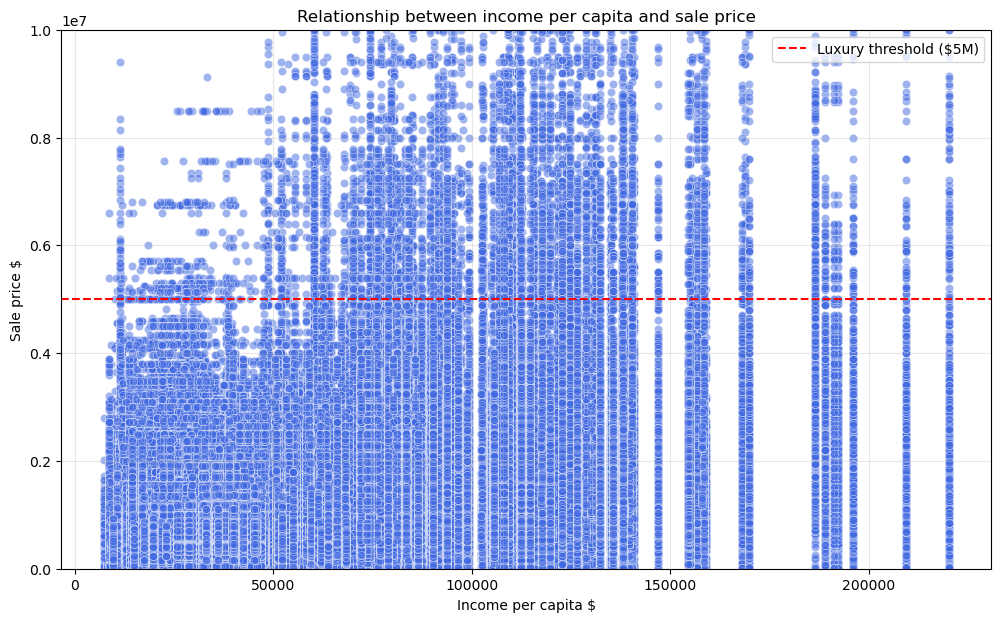

In [138]:
plt.figure(figsize = (12, 7))
sns.scatterplot(data = merged_dataset, x = 'income_per_cap', y ='sale_price', alpha = 0.5, color = 'royalblue')
#Add horizontal line which shows where is the $5 mln boundary
plt.axhline(y=5000000, color='red', linestyle='--', label='Luxury threshold ($5M)')
plt.title('Relationship between income per capita and sale price')
plt.xlabel('Income per capita $')
plt.ylabel('Sale price $')
plt.legend(loc='upper right')
plt.grid(True, alpha = 0.3)
plt.ylim(0, 10000000) 
plt.show()


The visualization clearly demonstrates the disconnect between local income levels and high-value property sales. The red dashed line at $5M shows the threshold where local purchasing power typically ends. While most transactions cluster below this line, we observe significant outliers even in mid-income areas. To reveal the true socio-economic correlation, we will remove these investment-driven outliers and normalize the data.

In [121]:
merged_dataset['sale_price'].skew()

np.float64(18.592394478772807)

In statistics any value above 1.0 indicates a highly skewed distribution. This extreme result confirms that the dataset is dominated by high-value outliers that distort the mean and variance.

In [126]:
clean_dataset = merged_dataset[(merged_dataset['sale_price'] <= 5000000)].copy()

In [127]:
clean_dataset

,neighborhood,building_class_category,block,lot,address,zip_code,residential_units,commercial_units,total_units,land_square_feet,...,mean_commute,employed,private_work,public_work,self_employed,family_work,unemployment,borough,full_fips,zcta
0,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,38.9,1213,79.2,16.2,3.6,1.0,9.5,Manhattan,36061002000,10009
1,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,30.1,1392,88.3,2.4,9.3,0.0,4.8,Manhattan,36061002202,10009
2,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,40.0,1068,73.3,21.4,5.2,0.0,14.9,Manhattan,36061002400,10009
3,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,33.6,1980,79.1,16.0,4.9,0.0,5.7,Manhattan,36061002601,10009
4,Alphabet City,09 Coops - Walkup Apartments,373,40,"327 East 3 Street, 1C",10009,0,0,0,1825.5,...,32.2,2781,82.1,8.0,8.6,1.3,4.1,Manhattan,36061002602,10009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
869274,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,47.1,3638,68.7,29.0,2.2,0.0,3.9,Staten Island,36085020803,10309
869275,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,44.5,2672,75.9,20.8,3.3,0.0,3.0,Staten Island,36085020804,10309
869276,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,48.1,2569,70.2,29.8,0.0,0.0,4.6,Staten Island,36085024401,10309
869277,Woodrow,02 Two Family Dwellings,7351,60,49 Pitney Avenue,10309,2,0,2,4000.0,...,43.9,2234,74.4,22.5,3.1,0.0,7.8,Staten Island,36085024402,10309


In [128]:
clean_dataset['log_sale_price'] = np.log10(clean_dataset['sale_price'])

In [133]:
clean_dataset['log_sale_price'].skew()

np.float64(-0.49417308461497955)

We apply a logarithmic transformation $\log_{10}$ to the sale prices to normalize the distribution. Real estate data is right-skewed. By using logs, we reduce the impact of high-value variance and achieve a distribution closer to normal.

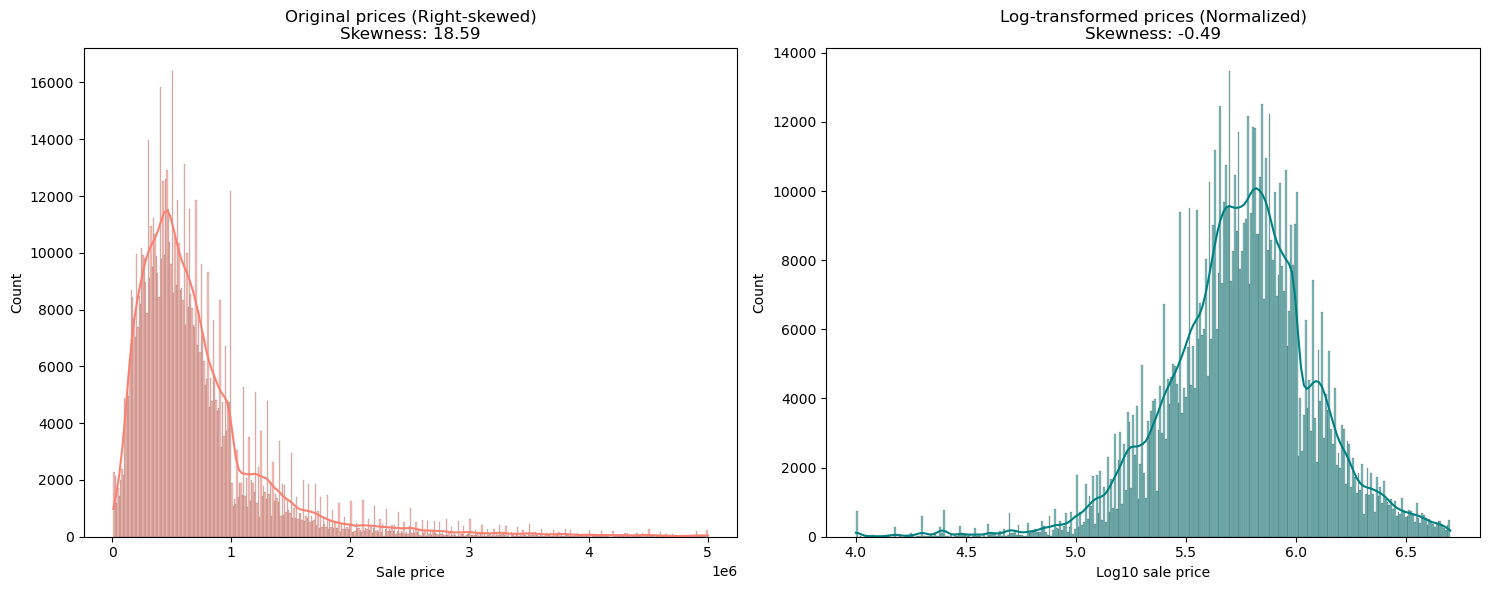

In [132]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

#Right-Skewed - sale_price
sns.histplot(clean_dataset['sale_price'], kde=True, ax=ax1, color='salmon')
ax1.set_title('Original prices (Right-skewed)\nSkewness: {:.2f}'.format(merged_dataset['sale_price'].skew()))
ax1.set_xlabel('Sale price')

#Normalized prices
sns.histplot(clean_dataset['log_sale_price'], kde=True, ax=ax2, color='teal')
ax2.set_title('Log-transformed prices (Normalized)\nSkewness: {:.2f}'.format(clean_dataset['log_sale_price'].skew()))
ax2.set_xlabel('Log10 sale price')

plt.tight_layout()
plt.show()


The comparison between the raw and transformed data highlights the necessity of our approach. The original distribution was extremely right-skewed - **18.59**, making standard statistical tests unreliable. After applying the $\log_{10}$
 transformation, we achieved an almost perfect normal distribution with a skewness of -0.49. This normalization allows us to accurately measure the impact of socio-economic factors on property values.